In [1]:
from transformers import AutoTokenizer, AutoModel
import torch
from decord import VideoReader, cpu

/data/home/eez086/.conda/envs/flash-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Setup
# model_path = "OpenGVLab/InternVideo2_5_Chat_8B"
model_path = "OpenGVLab/InternVL3-2B"

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(
    model_path,
    trust_remote_code=True,
)

model = AutoModel.from_pretrained(
    model_path,
    trust_remote_code=True,
    torch_dtype=torch.float16,
    device_map="auto",
    # use_flash_attention_2=True,
    attn_implementation="flash_attention_2",
).eval()

In [4]:
model

InternVLChatModel(
  (vision_model): InternVisionModel(
    (embeddings): InternVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
    )
    (encoder): InternVisionEncoder(
      (layers): ModuleList(
        (0): InternVisionEncoderLayer(
          (attn): InternAttention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (inner_attn): FlashAttention()
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (mlp): InternMLP(
            (act): GELUActivation()
            (fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affin

In [5]:
import numpy as np
import torch


def get_index(num_frames, num_segments):
    seg_size = float(num_frames - 1) / num_segments
    start = int(seg_size / 2)
    offsets = np.array(
        [start + int(np.round(seg_size * idx)) for idx in range(num_segments)]
    )
    return offsets


def load_video(video_path, num_segments=8):
    vr = VideoReader(video_path, ctx=cpu(0), num_threads=1)
    num_frames = len(vr)
    frame_indices = get_index(num_frames, num_segments)
    frames = vr.get_batch(frame_indices).asnumpy()  # (T, H, W, C)
    return frames


def preprocess_video_frames(frames, resolution=448):
    frames = (
        torch.from_numpy(frames).permute(0, 3, 1, 2).float() / 255.0
    )  # (T, C, H, W)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    frames = (frames - mean) / std
    frames = torch.nn.functional.interpolate(
        frames, size=(resolution, resolution), mode="bicubic", align_corners=False
    )
    return frames  # (T, 3, 448, 448)

In [6]:
from torch.utils.data import DataLoader
from data_load import PHOLPhysicsDataset

root = "path_to_the_data"


def collate_fn(batch):
    return {
        "scene_id": [item["scene_id"] for item in batch],
        "video": torch.stack([item["video"] for item in batch]),
        "qa": [item["qa"] for item in batch],
        "physical_props": [item["physical_props"] for item in batch],
        "taxonomy": [item["taxonomy"] for item in batch],
    }


dataset = PHOLPhysicsDataset(root=root, include_qa=True)
dataloader = DataLoader(
    dataset,
    batch_size=1,
    # shuffle=True,
    collate_fn=collate_fn,
)

all_dirs 4000
valid 4000
numeric 4000
non_numeric 0
 self.scenes  4000 0


In [7]:
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from transformers import AutoModel, AutoTokenizer
import math


def show_video_frames(
    video_path,
    num_segments=32,
    max_cols=8,
    min_cols=4,
    base_figsize=(16, 8),
    max_figsize=(24, 16),
):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video at {video_path}")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        print(f"Warning: Video at {video_path} has zero frames.")
        cap.release()
        return

    # Calculate optimal grid layout
    n_cols = min(max_cols, max(min_cols, math.isqrt(num_segments) + 1))
    n_rows = math.ceil(num_segments / n_cols)

    # Dynamically adjust figure size
    # fig_width = min(max_figsize[0], base_figsize[0] * (n_cols/min_cols))
    # fig_height = min(max_figsize[1], base_figsize[1] * (n_rows/(num_segments/max_cols)))
    # figsize = (fig_width, fig_height)
    cell_width, cell_height = 3, 3  # increase to make each frame bigger
    fig_width = n_cols * cell_width
    fig_height = n_rows * cell_height
    figsize = (fig_width, fig_height)

    # Get evenly spaced frame indices
    frame_indices = np.linspace(0, total_frames - 1, num_segments, dtype=int)

    # Read and store frames
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            print(f"Warning: Could not read frame {idx}. Skipping.")
            continue
        frames.append((idx, cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))

    cap.release()

    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    plt.suptitle(
        f"Video frames (total={total_frames}) → showing {len(frames)}/{num_segments} slices",
        fontsize=14,
        y=0.98,
    )

    # Flatten axes if needed
    if isinstance(axes, np.ndarray):
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    # Display frames
    for i, (frame_idx, frame_rgb) in enumerate(frames):
        ax = axes_flat[i]
        ax.imshow(frame_rgb)
        ax.set_title(f"Fr.{frame_idx + 1}", fontsize=8)
        ax.axis("off")

    # Hide unused axes
    for j in range(len(frames), len(axes_flat)):
        axes_flat[j].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [8]:
import torch
from transformers import AutoModel, AutoTokenizer


def build_dynamic_prompt(
    video_frames,
    taxonomy={},
    physical_props={},
    question="",
    options=None,
    explanation=None,
    num_patches_video=32,
    video_duration=15.0,
    fps=25,
):
    object_behaviors = []
    behavior_dict = {}

    # First collect all objects with valid behavior labels
    valid_objects = []
    for obj_id, frame_labels in taxonomy.items():
        all_labels = set()
        for labels in frame_labels:
            all_labels.update(
                label for label in labels if label
            )  # Filter empty strings
        if all_labels:
            valid_objects.append((obj_id, all_labels))

    # Now create numbered entries
    for i, (obj_id, all_labels) in enumerate(valid_objects, start=1):
        desc = f"{physical_props.get(obj_id, {}).get('color', 'unknown')} {physical_props.get(obj_id, {}).get('shape', 'object')}"
        behavior_entry = f"{i}. {desc}: {', '.join(sorted(all_labels))}"
        object_behaviors.append(behavior_entry)

        behavior_dict[obj_id] = {
            "description": desc,
            "behaviors": all_labels,
            "properties": physical_props.get(obj_id, {}),
            "number": i,
        }

    behavior_context = (
        "\n".join(object_behaviors)
        if object_behaviors
        else "No behavior labels available"
    )

    # video_context = ''.join(f"Frame {i+1}: <image>\n" for i in range(len(video_frames)))
    num_frames = num_patches_video
    frame_interval = video_duration / num_frames if num_frames > 0 else 0
    video_context = ""
    for i in range(num_frames):
        ts = i * frame_interval
        ts_str = f"{ts:.2f}s"
        video_context += f"Frame {i + 1} ({ts_str}): <image>\n"

    if physical_props:
        physical_props_str = "\n".join(
            f"{i + 1}. {v['color']} {v['shape']}: mass={v['mass']}, friction={v['friction'][0]:.2f}"
            for i, (k, v) in enumerate(physical_props.items())
        )
    else:
        physical_props_str = "No physical properties available"
        # print("physics_context_str", physics_context_str)

    additional_information = ""
    if options:
        additional_information = f"""
        Here are some options and you need to pick one of them based on your believes and calculations.
        Options: {options}
        """

    explanation_info = ""
    if explanation:
        explanation_info = f"""
        Explanations how to perform calculations: {explanation}
        """
    # Generate reasoning instructions based on available data
    reasoning_rules = [
        "1. Cross-reference visual evidence with the reported object behaviors",
        "2. Consider how physical properties affect the observed behaviors",
        "3. Analyze interactions between objects based on their behavior labels",
    ]

    if behavior_dict:
        specific_rules = [
            "4. For questions about motion, check these specific behaviors: "
            + ", ".join(
                {
                    b
                    for obj in behavior_dict.values()
                    for b in obj["behaviors"]
                    if "moving" in b.lower()
                    or "sliding" in b.lower()
                    or "rolling" in b.lower()
                }
            ),
            "5. For collision questions, verify these labels exist: "
            + ", ".join(
                {
                    b
                    for obj in behavior_dict.values()
                    for b in obj["behaviors"]
                    if "collision" in b.lower() or "contact" in b.lower()
                }
            ),
        ]
        reasoning_rules.extend(specific_rules)

    reasoning_instructions = "\n".join(reasoning_rules)

    return f"""
Answer the question using ONLY the provided evidence. Follow this strict protocol:

1. QUESTION CLASSIFICATION:
   Match question to these types (regex patterns from your template):
   - contact → "collide" or "contact" in question → yes/no
   - object_count → "How many distinct physical objects" → number
   - stop_count → "come to a complete stop" → number
   - rolling_count → "display rolling motion" → number
   - collision_objs → "unique objects involved in collision" → number
   - top_collider → "most collisions" → exact object name
   - kinetic_loss → "percentage of kinetic energy" → X%
   - collision_duration → "How long did collision" → Xs
   - stationary_time → "seconds spent stationary" → Xs
   - max_friction → "highest friction coefficient" → exact object name
   - yesno → any yes/no question → yes/no
   - count → "How many" → number
   - property → "What is the" → exact value/name

2. EVIDENCE SCANNING:
   - For counts: Check OBJECT BEHAVIORS
   - For properties: Check OBJECT PROPERTIES
   - For collisions: Require ≥2 objects with collision behaviors
   - For energy/time: Use mass + friction + behaviors

3. ANSWER SELECTION & FORMATTING:
   - You MUST select ONLY one from the provided options.
   - Format your answer to exactly match the selected option (e.g., "10.0%")
   - yes/no → lowercase, no punctuation
   - numbers → digits only (e.g. "3")
   - DO NOT explain, justify, or provide extra text.

Do not include any bullet points, numbering, or extra words. Output ONLY the final answer, exactly matching the format of the given options or expected value.

Video details:
 - Duration: 15 seconds
 - FPS: 25
 - Frames sampled: {num_patches_video}


OBJECT PROPERTIES:
{physical_props_str}

OBJECT BEHAVIORS:
{behavior_context}

QUESTION: {question}{explanation_info}{additional_information}
ANSWER:
""".strip()

In [9]:
def evaluate_with_dynamic_taxonomy(
    dataloader, model, tokenizer, root, max_samples=5, start_index=0, end_index=1000
):
    results = []
    count = 0
    num_patches_video = 32

    options = [
        {"is_taxonomy": False, "is_physics": False, "name": "no_additional_info"},
        {"is_taxonomy": True, "is_physics": False, "name": "taxonomy_only"},
        {"is_taxonomy": False, "is_physics": True, "name": "physics_only"},
        {"is_taxonomy": True, "is_physics": True, "name": "taxonomy_and_physics"},
    ]
    # for batch in tqdm(dataloader
    for batch_idx, batch in enumerate(tqdm(dataloader)):
        # batch = dataset[2829]
        # batch = dataset[1645]
        batch_size = len(batch["scene_id"])
        current_start = batch_idx * batch_size
        current_end = current_start + batch_size
        # Skip batches before our start index

        if current_end <= start_index:
            continue

        # Stop after reaching end index
        if current_start >= end_index:
            break

        if count >= max_samples:
            break
        count += 1

        # scene_id = batch['scene_id']
        scene_id = batch["scene_id"][0]

        video_path = f"{root}/{scene_id}/simulation_objects.mp4"
        # show_video_frames(video_path, num_segments=num_patches_video)

        # video_path = "/data/scratch/eez086/phlop/data/3/output_video.mp4"
        video_tensor = load_video(video_path, num_segments=num_patches_video)
        video_tensor = preprocess_video_frames(video_tensor, resolution=448)
        video_tensor = video_tensor.to(model.device)
        video_tensor = video_tensor.half()

        # print("Model response:", response)

        # # Load frames and ensure they're on the correct device
        # pixel_values, num_patches = load_video_frames_opencv(
        #     video_path, num_segments=num_patches_video, input_size=224
        # )
        # pixel_values = pixel_values.to(model.device, dtype=model.dtype)

        # # Ensure num_patches is on the correct device if it's a tensor
        # if isinstance(num_patches, torch.Tensor):
        #     num_patches = num_patches.to(model.device)

        taxonomy = batch["taxonomy"][0]
        physical_props = batch["physical_props"][0]
        qa_pairs = batch["qa"][0]
        # taxonomy = batch['taxonomy']
        # physical_props = batch['physical_props']
        # qa_pairs = batch['qa']

        for option in options:
            for qa in qa_pairs:
                prompt = build_dynamic_prompt(
                    video_frames=num_patches_video,
                    # taxonomy=taxonomy,
                    # physical_props=physical_props,
                    taxonomy=taxonomy if option["is_taxonomy"] else {},
                    physical_props=physical_props if option["is_physics"] else {},
                    question=qa["question"],
                    options=qa.get("options", None),
                    explanation=qa.get("explanation", None),
                )
                # print("+++"*5)
                # print(prompt)
                prompt_length = len(prompt.split())

                try:
                    with torch.no_grad():
                        response = model.chat(
                            tokenizer,
                            video_tensor,
                            question=prompt,
                            generation_config={
                                "do_sample": True,
                                "max_new_tokens": 200,
                                "temperature": 0.1,
                                "pad_token_id": tokenizer.pad_token_id
                                or tokenizer.eos_token_id,
                            },
                            # num_patches_list=num_patches,
                            history=None,
                        )
                except RuntimeError as e:
                    print(f"Error during generation: {e}")
                    response = "Error in generating response"

                eval_res = evaluate_response_quality(
                    response, qa["answer"], taxonomy, physical_props
                )

                # print("Question:", qa['question'], qa.get('options', None), qa.get("explanation", None))
                # print("Model response:", response)
                # print("True answer:", qa["answer"])
                # print("Scene ID:", scene_id)
                # print("-" * 80)

                results.append(
                    {
                        "scene_id": scene_id,
                        "question": qa["question"],
                        "answer": qa["answer"],
                        "answer_options": qa.get("options", None),
                        "response": response,
                        "correct": eval_res["correct"],
                        "error": eval_res["error"],
                        "option": option["name"],
                        "prompt_length": prompt_length,
                    }
                )
        # break
    return results


def evaluate_response_quality(response, true_answer, taxonomy, physical_props):
    def normalize_answer(ans):
        """Normalize answers for comparison"""
        if isinstance(ans, (list, tuple)):
            return [str(a).strip().lower() for a in ans]
        if isinstance(ans, (int, float)):
            return [str(float(ans))]
        ans = str(ans).strip().lower()
        if ans.startswith("no collision"):
            return ["0"]
        if ans in ["no collisions detected", "none"]:
            return ["0"]
        if ans.startswith("yes"):
            return ["yes"]
        if ans.startswith("no"):
            return ["no"]
        # Handle percentage and time strings
        if "%" in ans:
            ans = ans.replace("%", "")
        if ans.endswith("s") and ans[:-1].replace(".", "").isdigit():
            ans = ans[:-1]
        # Strip non-digit characters for numeric answers
        ans = "".join(c for c in ans if c.isdigit() or c in [".", "-"])
        return [ans]

    # Normalize both response and true answer(s)
    norm_response = normalize_answer(response)
    norm_true = normalize_answer(true_answer)

    # Case 1: Multiple correct answers (e.g., most collided objects)
    if isinstance(true_answer, (list, tuple)) or len(norm_true) > 1:
        # Check if any of the response items matches any true answer
        for resp_item in norm_response:
            if any(resp_item in true for true in norm_true):  # Fixed variable name here
                return {"correct": 1, "error": None}
        return {"correct": 0, "error": "value"}

    # Case 2: Numeric answers with tolerance
    try:
        resp_num = float(norm_response[0])
        true_num = float(norm_true[0])
        if abs(resp_num - true_num) <= 0.05 * abs(true_num):
            return {"correct": 1, "error": None}
        return {"correct": 0, "error": "value"}
    except (ValueError, TypeError):
        pass

    # Case 3: Exact string match
    if norm_response[0] == norm_true[0]:
        return {"correct": 1, "error": None}

    # Case 4: Substring match (for free-text answers)
    text_response = str(response).strip().lower()
    text_true = str(true_answer).strip().lower()
    if (text_response in text_true) or (text_true in text_response):
        return {"correct": 1, "error": None}

    # Case 5: Special cases (like "no collisions detected")
    special_cases = {"0": ["no collisions detected", "none", "no"], "1": ["yes"]}
    for key, aliases in special_cases.items():
        if (norm_true[0] == key and text_response in aliases) or (
            norm_response[0] == key and text_true in aliases
        ):
            return {"correct": 1, "error": None}

    # If nothing matches
    error_type = "format" if not norm_response[0] else "value"
    return {"correct": 0, "error": error_type}

In [10]:
torch.backends.cuda.enable_flash_sdp(True)
torch.cuda.empty_cache()
# root = "/data/scratch/eez086/phlop/data/"

# compare performance with/without taxonomy:
# baseline_acc = evaluate_vanilla_model()
# enhanced_acc = evaluate_with_dynamic_taxonomy(dataloader, model, tokenizer, root,
#                                               max_samples=35)

enhanced_acc = evaluate_with_dynamic_taxonomy(
    dataloader,
    model,
    tokenizer,
    root,
    start_index=2000,  # 0-based, so 500 means 501st sample
    end_index=4000,
    max_samples=2000,
)

  0%|          | 1/4000 [00:01<2:07:38,  1.92s/it]

  4%|▍         | 150/4000 [04:48<2:02:52,  1.91s/it]

  7%|▋         | 265/4000 [08:29<1:57:35,  1.89s/it]

  7%|▋         | 287/4000 [09:11<1:57:59,  1.91s/it]

 10%|█         | 404/4000 [12:55<1:54:43,  1.91s/it]

...

 86%|████████▋ | 3458/4000 [6:47:11<2:04:40, 13.80s/it]

 88%|████████▊ | 3514/4000 [7:01:18<2:02:02, 15.07s/it]

 94%|█████████▎| 3749/4000 [7:58:18<51:40, 12.35s/it]  

 97%|█████████▋| 3873/4000 [8:26:15<28:55, 13.67s/it]  

100%|██████████| 4000/4000 [8:56:37<00:00,  8.05s/it]


In [11]:
import json

# with open('./results/3-intern_socres-1.json', 'w') as f: #0 - 500
# with open('./results/3-intern_socres-2.json', 'w') as f: #500 - 2000
with open("./results/3-intern_socres-3.json", "w") as f:  # 2000 - 4000
    json.dump(enhanced_acc, f)

In [12]:
import pandas as pd
import json

file_list = [
    "./results/3-intern_socres-1.json",
    "./results/3-intern_socres-2.json",
    "./results/3-intern_socres-3.json",
]

dfs = []
# df = pd.DataFrame([pd.read_json(p, lines=True) for p in file_list])
for file in file_list:
    with open(file) as f:
        data = json.load(f)

    # data = pd.read_json(file, lines=True)
    print(type(data))
    dfs.extend(data)
    # break
# df = pd.DataFrame(dfs)
df = dfs
# temp = pd.concat(dfs, ignore_index=True)

<class 'list'>
<class 'list'>
<class 'list'>


In [19]:
df

[{'scene_id': '0',
  'question': 'Are there any moments in the video where two or more objects collide or make physical contact?',
  'answer': 'Yes',
  'answer_options': None,
  'response': 'no',
  'correct': 0,
  'error': 'value',
  'option': 'no_additional_info',
  'prompt_length': 294},
 {'scene_id': '0',
  'question': 'How many distinct physical objects appear during the video?',
  'answer': '5',
  'answer_options': None,
  'response': '1',
  'correct': 0,
  'error': 'value',
  'option': 'no_additional_info',
  'prompt_length': 286},
 {'scene_id': '0',
  'question': 'How many objects come to a complete stop during the video that we can see?',
  'answer': '1',
  'answer_options': None,
  'response': '0',
  'correct': 0,
  'error': 'value',
  'option': 'no_additional_info',
  'prompt_length': 292},
 {'scene_id': '0',
  'question': 'How many objects display rolling motion at any point in the video?',
  'answer': '3',
  'answer_options': None,
  'response': '0',
  'correct': 0,
  'erro

In [13]:
# enhanced_acc # with


def calculation(array):
    correct = list(filter(lambda x: x["correct"] == 1, array))
    return len(correct) / len(array)


# print(f"accuracy: {len(correct)/total :.2f}")

taxonomy_and_physics = list(
    filter(lambda x: x.get("option", "") == "taxonomy_and_physics", enhanced_acc)
)
no_additional_info = list(
    filter(lambda x: x.get("option", "") == "no_additional_info", enhanced_acc)
)
physics_only = list(
    filter(lambda x: x.get("option", "") == "physics_only", enhanced_acc)
)
taxonomy_only = list(
    filter(lambda x: x.get("option", "") == "taxonomy_only", enhanced_acc)
)
print(f"taxonomy_and_physics accuracy: {calculation(taxonomy_and_physics):.2f}")
print(f"physics_only accuracy: {calculation(physics_only):.2f}")
print(f"taxonomy_only accuracy: {calculation(taxonomy_only):.2f}")
print(f"no_additional_info accuracy: {calculation(no_additional_info):.2f}")


# total = len(enhanced_acc)
# correct = list(filter(lambda x: x["correct"] == 1, enhanced_acc))
# print(f"accuracy: {len(correct)/total :.2f}")

taxonomy_and_physics accuracy: 0.27
physics_only accuracy: 0.24
taxonomy_only accuracy: 0.30
no_additional_info accuracy: 0.25


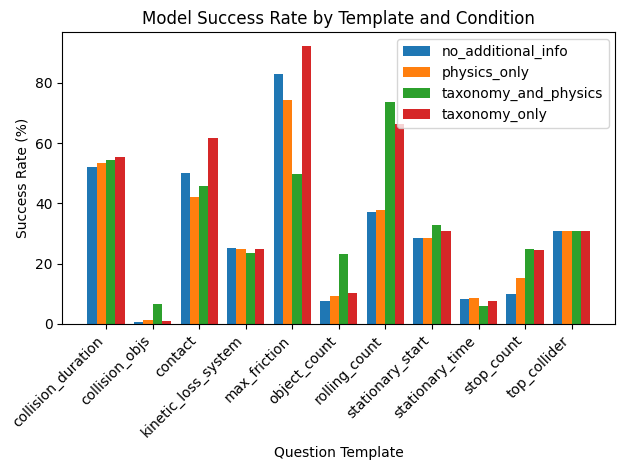

In [14]:
import re

# Build your DataFrame
df = pd.DataFrame(dfs)
# df = pd.DataFrame(enhanced_acc)

# 1) Tag each row with its template, including fallbacks
TEMPLATE_PATTERNS = [
    (
        "contact",
        r"^Are there any moments in the video where two or more objects collide or make physical contact\?$",
    ),
    ("object_count", r"^How many distinct physical objects appear during the video\?$"),
    (
        "stop_count",
        r"^How many objects come to a complete stop during the video that we can see\?$",
    ),
    (
        "rolling_count",
        r"^How many objects display rolling motion at any point in the video\?$",
    ),
    (
        "collision_objs",
        r"^How many unique objects were involved in collision throughout the video\?$",
    ),
    # ("top_collider", r"^Which object(?:\(s\))? were involved in the most collisions with other objects\?$"),
    (
        "top_collider",
        r"^Which object (?:was|were) involved in the most collisions with other objects\?$",
    ),
    # ("kinetic_loss_system",
    #                     r"^What percentage of the system(?:’|'s) kinetic energy was lost when the .+ collided with the .+\?$"),
    (
        "kinetic_loss_system",
        r"^What percentage of the system[’']s kinetic energy was lost when the .+ collided with the .+\?$",
    ),
    # ("kinetic_loss_system",
    #                     r"^What percentage of the system(?:’|'s) kinetic energy was lost when the .+ collided with the .+\?$"),
    (
        "kinetic_loss_obj",
        r"^How much kinetic energy did .+ lose during the collision\?$",
    ),
    # ("collision_duration", r"^How long did the collision between .+ and .+ last \(video fps is \d+\)\\?$"),
    (
        "collision_duration",
        r"^How long did the collision between .+ and .+ last \(video fps is \d+\)\?$",
    ),
    # How long did the collision between darkcyan sphere and hotpink sphere last (video fps is 25)?
    # ("collision_duration",
    #                     r"^How long did the collision between the .+ and the .+ last(?: \(video fps is \d+\))?\?$"),
    ("stationary_time", r"^How many seconds did the .+ spend stationary\?$"),
    (
        "stationary_start",
        r"^At what time in the video does the .+ first become stationary\?$",
    ),
    ("max_friction", r"^Which object had the highest friction coefficient\?$"),
    # FALLBACKS
    ("yesno", r"^(?:Are|Is|Do|Does|Has|Have|Can|Could|Will|Would).*\?$"),
    ("count", r"^How many .+\?$"),
    ("property", r"^What (?:is|are) the .+\?$"),
]
# Which object(s) were involved in the most collisions with other objects?


def assign_template(q):
    for name, pat in TEMPLATE_PATTERNS:
        if re.match(pat, q):
            return name
    print("q", q)
    return "unknown"


df["template"] = df["question"].apply(assign_template)

# 2) (Optionally) inspect how many fell into 'unknown'
n_unknown = (df["template"] == "unknown").sum()
if n_unknown > 0:
    print(
        f"⚠️  {n_unknown} questions didn’t match any pattern and are labeled 'unknown'."
    )

# 3) Drop unknowns before plotting
df = df[df["template"] != "unknown"]

# 4) Summarize and pivot
summary = (
    df.groupby(["template", "option"])
    .agg(n_total=("correct", "count"), n_correct=("correct", "sum"))
    .reset_index()
)
summary["success_pct"] = summary["n_correct"] / summary["n_total"] * 100
pivot = summary.pivot(index="template", columns="option", values="success_pct").fillna(
    0
)

# 5) If pivot is empty, bail out
if pivot.empty:
    print("❗ No templates remained after filtering — check your patterns.")
else:
    # 6) Plot
    labels = pivot.index.tolist()
    x = np.arange(len(labels))
    width = 0.2

    fig, ax = plt.subplots()
    for i, opt in enumerate(pivot.columns):
        ax.bar(x + i * width, pivot[opt], width, label=opt)

    ax.set_xticks(x + width * (len(pivot.columns) - 1) / 2)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel("Question Template")
    ax.set_ylabel("Success Rate (%)")
    ax.set_title("Model Success Rate by Template and Condition")
    ax.legend()

    plt.tight_layout()
    plt.show()